# IMPORTS DUH

In [ ]:
from pyod.utils.data import generate_data
from matplotlib import pyplot as plt
from pyod.models.knn import KNN
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, roc_curve
import numpy as np

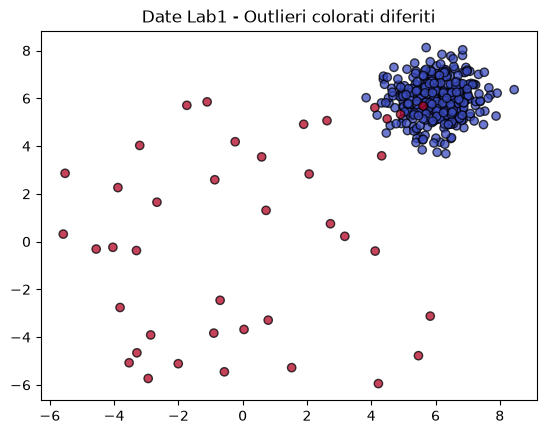

In [13]:
# EX 1 - generate data and scatter them

values = generate_data(n_train=400, n_test=100, n_features=2, contamination=0.1)
X_train = values[0]
Y_train = values[2]

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=Y_train,
    cmap="coolwarm",
    edgecolor="k",
    alpha=0.75,
)
plt.title("Date Lab1 - Outlieri colorati diferiti")
plt.show()

Train Performance:
TN: 359, FP: 1, FN: 1, TP: 39
Balanced Accuracy: 0.9861

Test Performance:
TN: 89, FP: 1, FN: 0, TP: 10
Balanced Accuracy: 0.9944



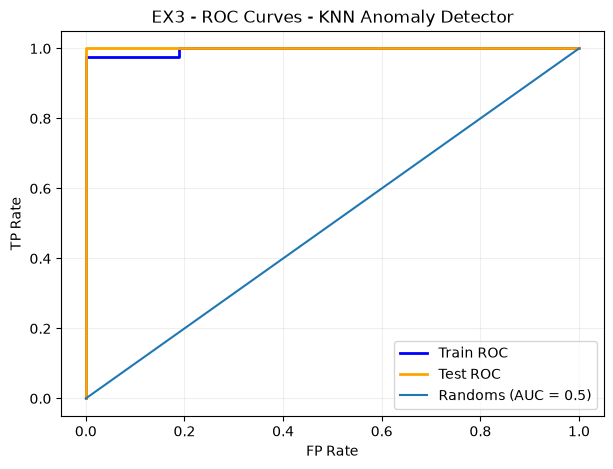

Testing with different contamination rates:
Contamination Rate: 0.05
TN: 90, FP: 0, FN: 4, TP: 6
Balanced Accuracy: 0.8000

Contamination Rate: 0.1
TN: 89, FP: 1, FN: 0, TP: 10
Balanced Accuracy: 0.9944

Contamination Rate: 0.15
TN: 78, FP: 12, FN: 0, TP: 10
Balanced Accuracy: 0.9333

Contamination Rate: 0.2
TN: 75, FP: 15, FN: 0, TP: 10
Balanced Accuracy: 0.9167



In [ ]:
# EX 2

contamination = 0.1

# generate data - again bcs why not
X_train, X_test, Y_train, Y_test = generate_data(
    n_train = 400,
    n_test = 100,
    n_features = 2,
    contamination = contamination,
)

# initialize knn with matching contamination rate to the data generation
clf = KNN(contamination=contamination)

# fit on the training data
clf.fit(X_train)

# predictions for the training data
y_train_pred = clf.predict(X_train)
y_train_scores = clf.decision_function(X_train)

# predictions for the testing data
y_test_pred = clf.predict(X_test)
y_test_scores = clf.decision_function(X_test)

# function made to find the number of tn, tp, fn, fp and the balanced accuracy
def evaluate_performance(y_true, y_pred, split_name="Test"):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    print(f"{split_name} Performance:")
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print(f"Balanced Accuracy: {bal_acc:.4f}\n")

evaluate_performance(Y_train, y_train_pred, split_name="Train")
evaluate_performance(Y_test, y_test_pred, split_name="Test")

# compute ROC curves using continuous decision scores
fpr_train, tpr_train, _ = roc_curve(Y_train, y_train_scores)
fpr_test, tpr_test, _ = roc_curve(Y_test, y_test_scores)

# plot them curveeeez

plt.figure(figsize=(7, 5))
plt.plot(fpr_train, tpr_train, label="Train ROC", color="blue", lw=2)
plt.plot(fpr_test, tpr_test, label="Test ROC", color="orange", lw=2)
plt.plot([0, 1], [0, 1], label="Randoms (AUC = 0.5)")

plt.title("EX3 - ROC Curves - KNN Anomaly Detector")
plt.xlabel("FP Rate")
plt.ylabel("TP Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.show()

# testing them with different contamination rates !!!!!!!!
print("Testing with different contamination rates:")

test_rates = [0.05, 0.1, 0.15, 0.2]

for rate in test_rates:
    temp_clf = KNN(contamination=rate)
    temp_clf.fit(X_train)

    preds = temp_clf.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(Y_test, preds).ravel()
    bal_acc = balanced_accuracy_score(Y_test, preds)

    print(f"Contamination Rate: {rate}")
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print(f"Balanced Accuracy: {bal_acc:.4f}\n")
    

In [ ]:
# EX 3

contamination = 0.1

X_train, _, Y_train, _ = generate_data(n_train=1000, n_features=1, contamination=contamination)



